DATASET OVERVIEW
Shape: (20, 17)

Columns:
Index(['Order ID', 'Order Date', 'Ship Mode', 'Customer ID', 'Customer Name',
       'Segment', 'Country', 'City', 'State', 'Region', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

Missing Values:
Order ID         0
Order Date       0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate Rows: 0

Summary Statistics:
             Sales   Quantity   Discount      Profit
count    20.000000  20.000000  20.000000   20.000000
mean    427.835000   2.900000   0.052500   78.199000
std     446.042906   1.333772   0.088071  127.620585
min      15.550000   1.000000   0.000000  -96.540000
25%      62.857500   2.000000   0.000000 

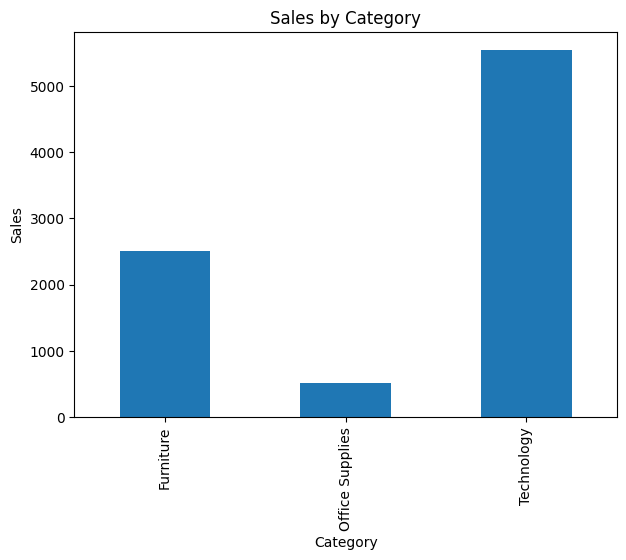

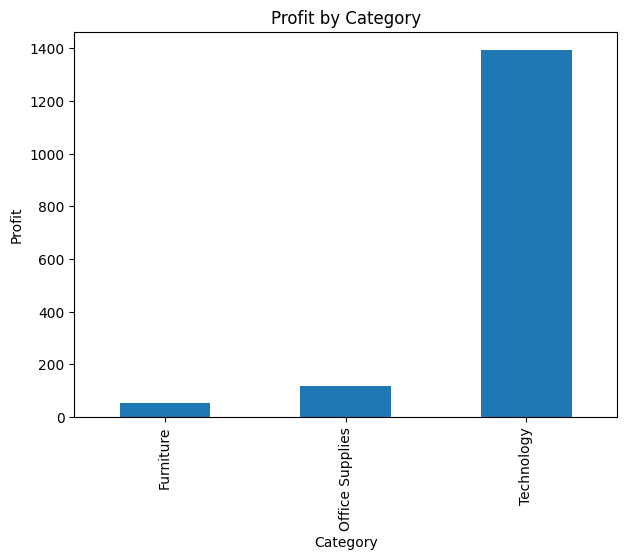

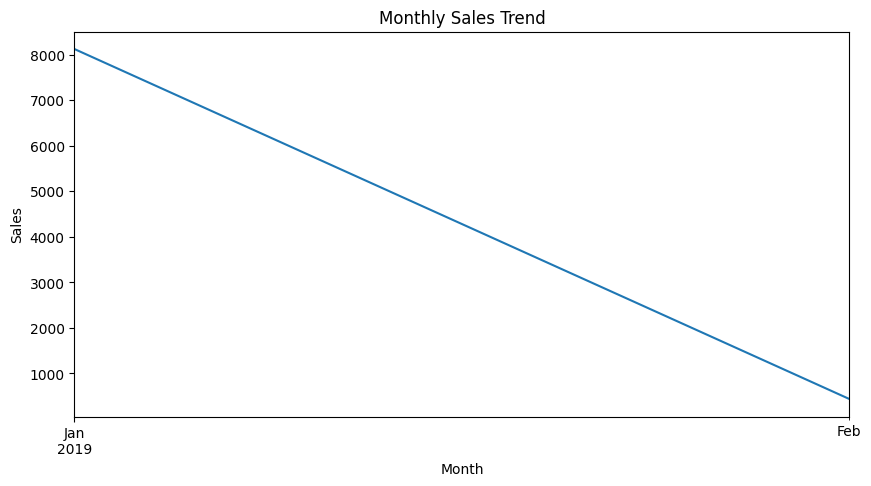

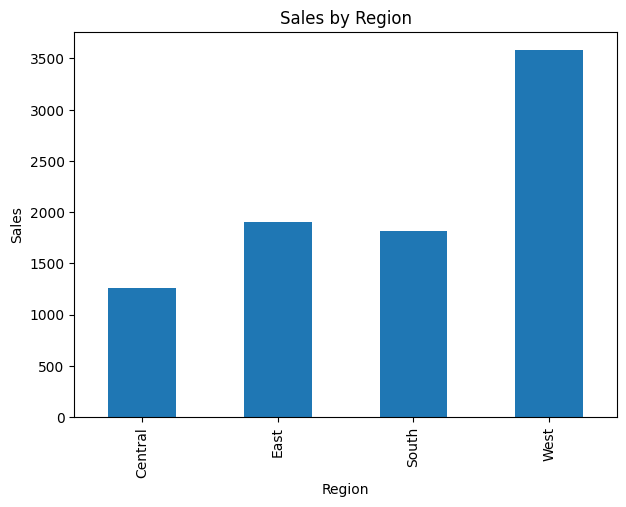


BUSINESS CONCLUSION


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, pearsonr, chi2_contingency
# Load Dataset
df = pd.read_csv("superstore.csv", encoding="latin1")

# ----------------------------
# Dataset Overview
# ----------------------------
print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nSummary Statistics:")
print(df.describe())

# ============================================================
# BUSINESS INSIGHTS
# ============================================================

print("\n========== SALES BY CATEGORY ==========")
print(df.groupby("Category")["Sales"].sum().sort_values(ascending=False))

print("\n========== PROFIT BY CATEGORY ==========")
print(df.groupby("Category")["Profit"].sum().sort_values(ascending=False))

print("\n========== SALES BY REGION ==========")
print(df.groupby("Region")["Sales"].sum().sort_values(ascending=False))

print("\n========== TOP 10 PRODUCTS ==========")
print(df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10))

# ============================================================
# CORRELATION TEST
# Business Question:
# Does Discount affect Profit?
# ============================================================

print("\n========== CORRELATION TEST ==========")

corr, p = pearsonr(df["Discount"], df["Profit"])

print("Correlation Coefficient :", round(corr,3))
print("P-value :", p)

if p < 0.05:
    print("Conclusion: Discount significantly affects Profit.")
else:
    print("Conclusion: No significant relationship found.")

# ============================================================
# T-TEST
# Business Question:
# Do Consumer and Corporate customers spend differently?
# ============================================================

print("\n========== T-TEST ==========")

consumer = df[df["Segment"]=="Consumer"]["Sales"]
corporate = df[df["Segment"]=="Corporate"]["Sales"]

t_stat, p_value = ttest_ind(consumer, corporate)

print("T Statistic :", round(t_stat,3))
print("P-value :", p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("Consumer and Corporate sales differ significantly.")
else:
    print("Fail to Reject Null Hypothesis")
    print("No significant difference between Consumer and Corporate sales.")

# ============================================================
# CHI-SQUARE TEST
# Business Question:
# Is Region associated with Category?
# ============================================================

print("\n========== CHI-SQUARE TEST ==========")

table = pd.crosstab(df["Region"], df["Category"])

chi2, p, dof, expected = chi2_contingency(table)

print("Chi-Square Value :", round(chi2,3))
print("Degrees of Freedom :", dof)
print("P-value :", p)

if p < 0.05:
    print("Conclusion: Region and Category are associated.")
else:
    print("Conclusion: No association found.")

# ============================================================
# VISUALIZATION 1
# Sales by Category
# ============================================================

sales_category = df.groupby("Category")["Sales"].sum()

plt.figure(figsize=(7,5))
sales_category.plot(kind="bar")
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

# ============================================================
# VISUALIZATION 2
# Profit by Category
# ============================================================

profit_category = df.groupby("Category")["Profit"].sum()

plt.figure(figsize=(7,5))
profit_category.plot(kind="bar")
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

# ============================================================
# VISUALIZATION 3
# Monthly Sales Trend
# ============================================================

df["Order Date"] = pd.to_datetime(df["Order Date"], format='%d-%m-%Y')

df["Month"] = df["Order Date"].dt.to_period("M")

monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

# ============================================================
# VISUALIZATION 4
# Sales by Region
# ============================================================

sales_region = df.groupby("Region")["Sales"].sum()

plt.figure(figsize=(7,5))
sales_region.plot(kind="bar")
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

# ============================================================
# FINAL BUSINESS CONCLUSION
# ============================================================

print("\n======================================================")
print("BUSINESS CONCLUSION")
print("======================================================")



